 ## preparation of the decomposed automaton

In [ ]:
# generate n chains of length m, where n and m are given by the user, default n = 5, m = 10
# fix some order of the chains
# add dependencies on the edges such that the edge of one chain depends on the states of later chains (not the previous ones in the fixed order)
# the number of states on which a given edge depends is chosen uniformly from {0,1, 2, 3}..if there are multiple states, they need to be from different chains.

import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import random
n = 8
m = 12

def gen_chains(n=n, m=m):
    chains = defaultdict(list)

    for i in range(n):
        G = nx.Graph()
        nodes = [j for j in range(m)]
        edges = list(zip(nodes[:-1], nodes[1:]))

        G.add_edges_from(edges)
        chains[i] = G

    return chains

def add_enabling(chains):
    n = len(chains)
    
    for chain_id in range(n-1):
        G = chains[chain_id]
        
        for edge in G.edges():
            if random.random() < 0.5:
                num_deps = random.randint(0, 3)
                
                if num_deps > 0:
                    later_chains = list(range(chain_id + 1, n))
                    selected_chains = random.sample(later_chains, min(num_deps, len(later_chains)))
                    
                    enabling_conditions = []
                    for enabling_chain in selected_chains:
                        enabling_G = chains[enabling_chain]
                        enabling_node = random.choice(list(enabling_G.nodes()))
                        enabling_conditions.append({'automata_id':enabling_chain,'node_id':enabling_node})
                    
                    G.edges[edge]['enabling'] = enabling_conditions
    
    return chains

chains = add_enabling(gen_chains())
chains2 = add_enabling(gen_chains())

In [30]:
def add_list_to_edges(graph):
    for chain_id in range(len(graph)):
        G = graph[chain_id]
        for edge in G.edges(data=True):
            if 'enabling' in edge[2]:
                edge[2]['enabling'] = [edge[2]['enabling']]
                

In [31]:
import random
import pickle

def update_chain_rules(chain, num):
    for i in range(len(chain)):
        for edge in chain[i].edges(data=True):
            if 'enabling' in edge[2]:
                for enabling in edge[2]['enabling']:
                    enabling['automata_id'] = enabling['automata_id'] - num

def get_automata_with_dependent_chains(num=None):
    found = False
    while not found:
        chain = add_enabling(gen_chains())
        if num <= 1:
            return chain
        
        for i in range(num, 1, -1):
            for edge in chain[n-i].edges(data=True):
                if 'enabling' in edge[2]:
                    found = True
                    break
                else:
                    found = False
        
        if found:
            return chain

def crossbreed(chain1, chain2):
    new_automata = add_enabling(gen_chains())

    res_graph = defaultdict(list)
    res_graph[0] = new_automata[n-1]
    res_graph[1] = chain1[n-4]
    res_graph[2] = chain1[n-3]
    res_graph[3] = chain1[n-2]
    res_graph[4] = chain1[n-1]
    res_graph[5] = chain2[n-3]
    res_graph[6] = chain2[n-2]
    res_graph[7] = chain2[n-1]
    
    random_edge1 = random.randint(0, m-2)
    while True:
        random_edge2 = random.randint(0, m-2)
        if random_edge1 != random_edge2:
            break

    res_graph[0].edges[random_edge1, random_edge1+1]['enabling'] = [{'automata_id': 1, 'node_id': random.randint(0, m-1)}]
    res_graph[0].edges[random_edge2, random_edge2+1]['enabling'] = [{'automata_id': 4, 'node_id': random.randint(0, m-1)}]

    add_list_to_edges(new_automata)

    return res_graph


automata1 = get_automata_with_dependent_chains(num=4)
update_chain_rules(automata1, num=abs(1-4))

automata2 = get_automata_with_dependent_chains(num=3)
update_chain_rules(automata2, num=abs(5-5))


res_G = crossbreed(automata1, automata2)

add_list_to_edges(automata1)
add_list_to_edges(automata2)
# add_list_to_edges(res_G)

with open('automata1.pkl', 'wb') as f:
    pickle.dump(automata1, f)
with open('automata2.pkl', 'wb') as f:
    pickle.dump(automata2, f)
with open('res_G.pkl', 'wb') as f:
    pickle.dump(res_G, f)

In [32]:
def print_graph_rules(graph):
    for chain_id in range(len(graph)):
        print(f"\nChain {chain_id}:")
        G = graph[chain_id]
        for edge in G.edges(data=True):
            print(f"Edge {edge[0]} -> {edge[1]}: {edge[2]}")

print_graph_rules(res_G)


Chain 0:
Edge 0 -> 1: {}
Edge 1 -> 2: {}
Edge 2 -> 3: {}
Edge 3 -> 4: {}
Edge 4 -> 5: {'enabling': [[{'automata_id': 1, 'node_id': 5}]]}
Edge 5 -> 6: {}
Edge 6 -> 7: {'enabling': [[{'automata_id': 4, 'node_id': 6}]]}
Edge 7 -> 8: {}

Chain 1:
Edge 0 -> 1: {}
Edge 1 -> 2: {}
Edge 2 -> 3: {}
Edge 3 -> 4: {}
Edge 4 -> 5: {}
Edge 5 -> 6: {}
Edge 6 -> 7: {}
Edge 7 -> 8: {}

Chain 2:
Edge 0 -> 1: {}
Edge 1 -> 2: {}
Edge 2 -> 3: {'enabling': [[{'automata_id': 3, 'node_id': 4}, {'automata_id': 4, 'node_id': 4}]]}
Edge 3 -> 4: {}
Edge 4 -> 5: {'enabling': [[{'automata_id': 3, 'node_id': 0}, {'automata_id': 4, 'node_id': 3}]]}
Edge 5 -> 6: {}
Edge 6 -> 7: {}
Edge 7 -> 8: {}

Chain 3:
Edge 0 -> 1: {'enabling': [[{'automata_id': 4, 'node_id': 3}]]}
Edge 1 -> 2: {}
Edge 2 -> 3: {}
Edge 3 -> 4: {'enabling': [[{'automata_id': 4, 'node_id': 7}]]}
Edge 4 -> 5: {}
Edge 5 -> 6: {}
Edge 6 -> 7: {}
Edge 7 -> 8: {'enabling': [[{'automata_id': 4, 'node_id': 4}]]}

Chain 4:
Edge 0 -> 1: {}
Edge 1 -> 2: {}
Ed

/home/jan/miniconda3/envs/sos/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:312: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)


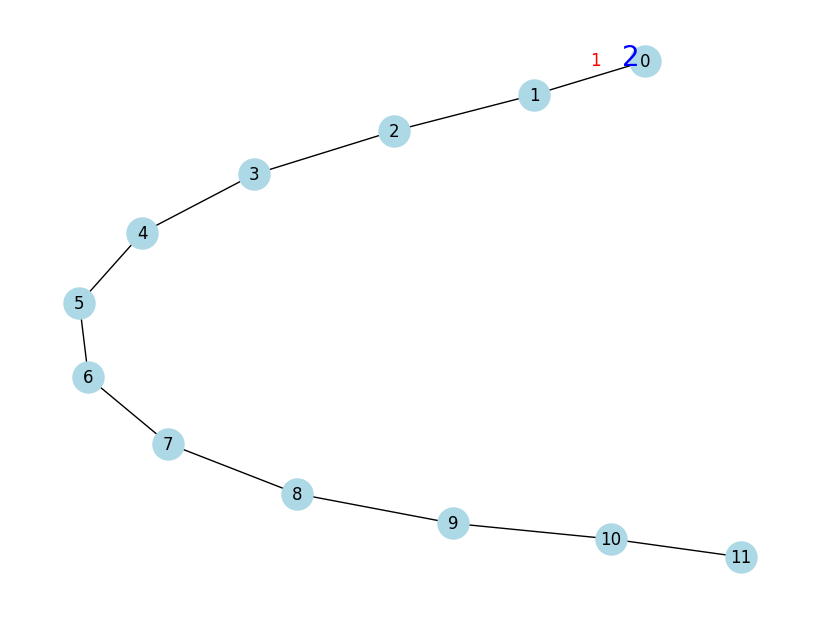

In [5]:
# Create a new figure
plt.figure(figsize=(8,6))

# Create a directed graph
G = res_G[0]

# Set up the layout
pos = nx.spring_layout(G)

# Draw the graph
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=500, arrowsize=20)

# Create edge labels with different colors
edge_labels = {(0,1): ''}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Add the colored numbers separately
# Get the edge midpoint position
edge_pos = pos[0] + (pos[1] - pos[0]) * 0.5
plt.text(edge_pos[0], edge_pos[1]+0.05, '1', color='red', fontsize=12)
plt.text(edge_pos[0]+0.05, edge_pos[1]+0.05, '2', color='blue', fontsize=20)

plt.axis('off')
plt.show()


In [6]:
print(chains[0].edges[(1,2)])

{}


In [7]:
for chain_id in range(len(chains)):
    print(f"\nChain {chain_id}:")
    G = chains[chain_id]
    for edge in G.edges(data=True):
        print(f"Edge {edge[0]} -> {edge[1]}: {edge[2]}")


Chain 0:
Edge 0 -> 1: {'enabling': [{'automata_id': 2, 'node_id': 8}, {'automata_id': 7, 'node_id': 9}]}
Edge 1 -> 2: {}
Edge 2 -> 3: {}
Edge 3 -> 4: {}
Edge 4 -> 5: {}
Edge 5 -> 6: {}
Edge 6 -> 7: {}
Edge 7 -> 8: {}
Edge 8 -> 9: {'enabling': [{'automata_id': 4, 'node_id': 6}, {'automata_id': 2, 'node_id': 4}, {'automata_id': 3, 'node_id': 4}]}
Edge 9 -> 10: {}
Edge 10 -> 11: {}

Chain 1:
Edge 0 -> 1: {}
Edge 1 -> 2: {'enabling': [{'automata_id': 6, 'node_id': 9}]}
Edge 2 -> 3: {'enabling': [{'automata_id': 5, 'node_id': 1}, {'automata_id': 6, 'node_id': 2}, {'automata_id': 7, 'node_id': 1}]}
Edge 3 -> 4: {'enabling': [{'automata_id': 3, 'node_id': 3}]}
Edge 4 -> 5: {'enabling': [{'automata_id': 6, 'node_id': 4}]}
Edge 5 -> 6: {}
Edge 6 -> 7: {'enabling': [{'automata_id': 3, 'node_id': 3}, {'automata_id': 7, 'node_id': 4}]}
Edge 7 -> 8: {}
Edge 8 -> 9: {}
Edge 9 -> 10: {}
Edge 10 -> 11: {}

Chain 2:
Edge 0 -> 1: {}
Edge 1 -> 2: {'enabling': [{'automata_id': 5, 'node_id': 6}, {'automat

In [8]:
chains[0].nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11))

## creation of 1 sample problem

In [9]:
# for the fixed order of chains, create a vector of states for each chain. states in different chains are chosen randomly.
# choose 1 chain as the target chain
# choose a random target state in the target chain
# the result is sample = {"input": vector of states, "target": target state, "target chain": target chain}

In [10]:
def get_vectors(chains, max_combinations=300_000, max_states_per_chain=20):
    """
    Get all possible state combinations across automata with safety limits.
    
    Args:
        chains: Dictionary of networkx graphs representing automata
        max_combinations: Maximum number of combinations to generate (default: 100,000)
        max_states_per_chain: Maximum states per automaton to consider (default: 20)
    
    Returns:
        List of tuples representing all possible state combinations
    """
    states_per_chain = []
    
    # Safety check: ensure chains is not empty
    if not chains:
        print("Warning: No chains provided")
        return []
    
    # Calculate potential size before processing
    total_combinations = 1
    
    for chain_id in range(len(chains)):
        if chain_id not in chains:
            print(f"Warning: Missing chain_id {chain_id}")
            continue
            
        graph = chains[chain_id]
        
        # Safety check: ensure graph has nodes
        nodes = list(graph.nodes())
        if not nodes:
            print(f"Warning: Chain {chain_id} has no nodes")
            return []
        
        # Limit states per chain to prevent explosion
        if len(nodes) > max_states_per_chain:
            print(f"Warning: Chain {chain_id} has {len(nodes)} states, limiting to {max_states_per_chain}")
            nodes = nodes[:max_states_per_chain]
        
        states_per_chain.append(nodes)
        total_combinations *= len(nodes)
        
        # Early exit if combinations would exceed limit
        if total_combinations > max_combinations:
            print(f"Error: Potential combinations ({total_combinations:,}) exceed limit ({max_combinations:,})")
            print(f"Consider reducing number of automata or states per automaton")
            print(f"Current automata states: {[len(states) for states in states_per_chain]}")
            
            # Try to salvage by reducing states in problematic chains
            while total_combinations > max_combinations and states_per_chain:
                # Find the chain with most states and reduce it
                max_idx = max(range(len(states_per_chain)), key=lambda i: len(states_per_chain[i]))
                if len(states_per_chain[max_idx]) <= 2:
                    # Can't reduce further, return empty
                    print("Cannot reduce further while maintaining at least 2 states per chain")
                    return []
                
                # Remove one state from the largest chain
                states_per_chain[max_idx] = states_per_chain[max_idx][:-1]
                
                # Recalculate total
                total_combinations = 1
                for states in states_per_chain:
                    total_combinations *= len(states)
                
                print(f"Reduced to {total_combinations:,} combinations")
            
            if total_combinations > max_combinations:
                print("Still too many combinations after reduction")
                return []
    
    print(f"Generating {total_combinations:,} state combinations...")
    
    try:
        # Use itertools.product with the unpacked states
        from itertools import product
        result = list(product(*states_per_chain))
        
        # Double-check the result size
        if len(result) > max_combinations:
            print(f"Warning: Generated {len(result):,} combinations, truncating to {max_combinations:,}")
            result = result[:max_combinations]
        
        print(f"Successfully generated {len(result):,} combinations")
        return result
        
    except MemoryError:
        print("Memory error encountered while generating combinations")
        return []
    except Exception as e:
        print(f"Error generating combinations: {e}")
        return []


vecs = get_vectors(chains)

Error: Potential combinations (2,985,984) exceed limit (300,000)
Consider reducing number of automata or states per automaton
Current automata states: [12, 12, 12, 12, 12, 12]
Reduced to 2,737,152 combinations
Reduced to 2,509,056 combinations
Reduced to 2,299,968 combinations
Reduced to 2,108,304 combinations
Reduced to 1,932,612 combinations
Reduced to 1,771,561 combinations
Reduced to 1,610,510 combinations
Reduced to 1,464,100 combinations
Reduced to 1,331,000 combinations
Reduced to 1,210,000 combinations
Reduced to 1,100,000 combinations
Reduced to 1,000,000 combinations
Reduced to 900,000 combinations
Reduced to 810,000 combinations
Reduced to 729,000 combinations
Reduced to 656,100 combinations
Reduced to 590,490 combinations
Reduced to 531,441 combinations
Reduced to 472,392 combinations
Reduced to 419,904 combinations
Reduced to 373,248 combinations
Reduced to 331,776 combinations
Reduced to 294,912 combinations
Error: Potential combinations (3,538,944) exceed limit (300,000)

In [11]:
from tqdm import tqdm
id_2_vec = {}
vec_2_id = {}
for i, comb in tqdm(enumerate(vecs)):
    id_2_vec[i] = comb
    vec_2_id[comb] = i

250000it [00:00, 3073551.78it/s]


In [12]:
def get_sample(vector, chains):
    num_chains = len(chains)
    num_states = len(chains[0].nodes())
    
    target_chain = random.randint(0, num_chains-1)

    target_state = random.randint(0, num_states-1)
    
    return {
        'input': list(vector),
        'target_state': target_state,
        'target_chain': target_chain
    }

In [13]:
sample = get_sample(vecs[122], chains)
sample

{'input': [0, 0, 0, 0, 0, 4, 4, 2], 'target_state': 0, 'target_chain': 1}

## implementation of the solver

In [14]:
sample = {'input': [1, 2, 2], 'target_state': 4, 'target_chain': 0}

In [15]:
steps_log = []
shortest_paths_log = []
target_log = []

def get_rule(chains, target_chain, cur_node, next_node):
    cur_rule = chains[target_chain].get_edge_data(cur_node, next_node)
    steps_log.append((target_chain, cur_node, next_node, cur_rule))
    return cur_rule

def get_shortest_path(chains, target_chain, current_state, target_state):
    shortest_path = nx.shortest_path(chains[target_chain],current_state[target_chain], target_state)
    shortest_paths_log.append((target_chain,shortest_path))
    return shortest_path

def solve(sample, chains, path=[]):
    target_chain = sample["target_chain"]
    target_state = sample["target_state"]
    target_log.append((target_chain, target_state))
    current_state = list(sample["input"])
    shortest_paths = get_shortest_path(chains, target_chain, current_state, target_state)
    for i, cur_node in enumerate(shortest_paths):
        if i < len(shortest_paths)-1:
            next_node = shortest_paths[i+1]
            cur_rule = get_rule(chains, target_chain, cur_node, next_node)
            if cur_rule == {}:
                path.append({"automata_id": target_chain, "state_change": (cur_node,next_node)})
                current_state[target_chain] = next_node

                continue
            else:
                for rules in cur_rule["enabling"]:
                    new_sample = {}
                    new_sample['input'] = current_state
                    new_sample["target_state"] = rules["node_id"]
                    new_sample['target_chain'] = rules["automata_id"]
                    path, current_state = solve(new_sample, chains, path)
                path.append({"automata_id": target_chain, "state_change": (cur_node,next_node)})
                current_state[target_chain] = next_node
                # after each dependency state is resolved, cross the edge and append it to the path and change the current state
                # after the shortest path to the target state if traversed, return the path and the current state
    return path, current_state

    # for the target chain, find all shortest paths from the current state to the target state
    # take the first path and try to traverse it. ie iterate over the edges and do the following:
    # # if the edge is not dependent on other states:
    # # # cross the edge, i.e. change the current state for the target chain to get one more step closer to the target state
    # # # path.append(edge)
    # # else get the dependency states, depenendet = edge['enabling']
    # # for each dependency state, do the following:
    # # # new_sample = {}
    # # # new_sample['input_states'] = current_state
    # # # new_sample["target"] = dependency_state
    # # # new_sample['target chain'] = chain of the dependency state
    # # # path, current_state = solve(new_sample,path)
    # # after each dependency state is resolved, cross the edge and append it to the path and change the current state
    # after the shortest path to the target state if traversed, return the path and the current state

In [16]:
solver_path = solve(sample, chains)
solver_path, len(solver_path[0])

(([{'automata_id': 0, 'state_change': (1, 2)},
   {'automata_id': 0, 'state_change': (2, 3)},
   {'automata_id': 0, 'state_change': (3, 4)}],
  [4, 2, 2]),
 3)

In [17]:
def group_automata(data):
    changes, finals = data
    result = []
    
    for change in changes:
        if result and result[-1]['automata_id'] == change['automata_id']:
            result[-1]['state_change'].append(change['state_change'])
        else:
            result.append({'automata_id': change['automata_id'], 
                         'state_change': [change['state_change']]})
            
    return (result, finals)

In [18]:
def group_rules(data):
    result = []
    
    for rule in data:
        if result and result[-1]['automata_id'] == rule[0]:
            result[-1]['state_change'].append(((rule[1], rule[2]), rule[3]))
        else:
            result.append({'automata_id': rule[0],  
                         'state_change': [((rule[1], rule[2]), rule[3])]})
            
    return result

In [19]:
rules_grp = group_rules(steps_log)
rules_grp, len(rules_grp)

([{'automata_id': 0,
   'state_change': [((1, 2), {}), ((2, 3), {}), ((3, 4), {})]}],
 1)

In [20]:
path_grp = group_automata(solver_path)
path_grp, len(path_grp[0])

(([{'automata_id': 0, 'state_change': [(1, 2), (2, 3), (3, 4)]}], [4, 2, 2]),
 1)

In [21]:
print([x['automata_id'] for x in rules_grp])
print([x['automata_id'] for x in path_grp[0]])

[0]
[0]


In [22]:
used_rules = []
for x in rules_grp:
    for y in x['state_change']:
        if y[1] != {}:
            used_rules.append((x['automata_id'],y))
for rule in used_rules:
    print(rule)
len(used_rules)

0

In [23]:
target_log,len(target_log)

([(0, 4)], 1)

In [24]:
def find_origin(condition):
    for rule in used_rules:
        for enabling in rule[1][1]['enabling']:
            if (enabling['automata_id'], enabling['node_id']) == condition:
                return (rule[0], rule[1][0])
            
    return None

***Prepare data for visualization***

In [25]:
# delete row in shortest_paths_log that contains only one instance
shortest_paths_log = [x for x in shortest_paths_log if len(x[1]) > 1]
shortest_paths_log, len(shortest_paths_log)

([(0, [1, 2, 3, 4])], 1)

In [26]:
full_path = []
previous_states = [state for state in sample['input']]
states = [state for state in sample['input']]
rules_grp_tmp = [x for x in rules_grp]

last_automata_id = path_grp[0][0]['automata_id']
last_next_state = path_grp[0][0]['state_change'][0][1]
shortest_paths_log_tmp = [(item[0], [i for i in item[1]]) for item in shortest_paths_log]

# BEGINNING PHASE
# Add steps that only show edges with conditions, no state change
for ruul in rules_grp_tmp:

    if ruul['automata_id'] != path_grp[0][0]['automata_id']:
        rules_grp_tmp = rules_grp_tmp[1:]
        for item in shortest_paths_log_tmp:
            if item[0] == ruul['automata_id'] and item[1] != []:
                current_shortest_path = item[1][:]
                break

        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                                'automata_id': ruul['automata_id'],
                                'states': [state for state in states],
                                'next_state': ruul['state_change'][0][0][0],
                                'shortest_path': current_shortest_path,
                                'edge': ruul['state_change'][0][0],
                                'conditions': {},
                                'debug_ID': "a",})
    else:
        break

# MAIN PHASE
for rules in path_grp[0]:
    
    # Assign current shortest path
    for item in shortest_paths_log_tmp:
        if item[0] == rules['automata_id'] and item[1] != []:
            current_shortest_path = item[1][:]
            item[1][:len(rules['state_change'])] = []
            break

    for i, state_change in enumerate(rules['state_change']):
        # Update state of last automata, needed when switching from one automata to other
        # states[last_automata_id] = last_next_state
        states[rules['automata_id']] = state_change[0]

        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                            'automata_id': rules['automata_id'],
                            'states': [state for state in states],
                            'next_state': state_change[1],
                            'shortest_path': current_shortest_path[:],
                            'edge': state_change,
                            'conditions': {},
                            'debug_ID': "b",})
        
        current_shortest_path[:1] = []
        
        last_automata_id = rules['automata_id']
        last_next_state = state_change[1]

    if(len(current_shortest_path) >= 2):

        states[rules['automata_id']] = state_change[1]
        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                            'automata_id': rules['automata_id'],
                            'states': [state for state in states],
                            'next_state': state_change[1],
                            'shortest_path': current_shortest_path,
                            'edge': (state_change[1], current_shortest_path[1]),
                            'conditions': {},
                            'debug_ID': "d",})
    else:
        states[rules['automata_id']] = state_change[1]
        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                            'automata_id': rules['automata_id'],
                            'states': [state for state in states],
                            'next_state': state_change[1],
                            'conditions': {},
                            'debug_ID': "e",})

visited = set()

for i, state in enumerate(full_path[0]['states']):
    visited.add((i, state))

# Logic for conditions

for condition in used_rules:
    for enabling in condition[1][1]['enabling']:
        val = None
        
        for i, step in enumerate(full_path):

            if 'shortest_path' in step and step['automata_id'] == enabling['automata_id'] and step['shortest_path'][-1] == enabling['node_id']:
                val = "solving"
            
            if step['automata_id'] == enabling['automata_id'] and 'shortest_path' not in step and step['states'][step['automata_id']] == enabling['node_id']:
                val = "solved"

            if val != None:
                if condition[0] not in step['conditions']:
                    step['conditions'][condition[0]] = {}

                if condition[1][0] not in step['conditions'][condition[0]]:
                    step['conditions'][condition[0]][condition[1][0]] = {}

                step['conditions'][condition[0]][condition[1][0]][(enabling['automata_id'], enabling['node_id'])] = val

In [27]:
full_path, len(full_path)

([{'target': {'automata_id': 0, 'state': 4},
   'automata_id': 0,
   'states': [1, 2, 2],
   'next_state': 2,
   'shortest_path': [1, 2, 3, 4],
   'edge': (1, 2),
   'conditions': {},
   'debug_ID': 'b'},
  {'target': {'automata_id': 0, 'state': 4},
   'automata_id': 0,
   'states': [2, 2, 2],
   'next_state': 3,
   'shortest_path': [2, 3, 4],
   'edge': (2, 3),
   'conditions': {},
   'debug_ID': 'b'},
  {'target': {'automata_id': 0, 'state': 4},
   'automata_id': 0,
   'states': [3, 2, 2],
   'next_state': 4,
   'shortest_path': [3, 4],
   'edge': (3, 4),
   'conditions': {},
   'debug_ID': 'b'},
  {'target': {'automata_id': 0, 'state': 4},
   'automata_id': 0,
   'states': [4, 2, 2],
   'next_state': 4,
   'conditions': {},
   'debug_ID': 'e'}],
 4)

In [28]:
print(full_path[17])
print(full_path[18])
print(full_path[19])
print(full_path[20])
print(full_path[21])
print(full_path[22])

IndexError: list index out of range

**Visualization**

In [ ]:
import visualize_search as vs
import importlib

importlib.reload(vs)

visualization = vs.Visualize_search(chains, full_path, sample['input'])
visualization.animate("test_visualization")